<a href="https://colab.research.google.com/github/Konwalai1111/BSC_DPDM2025/blob/main/Final_BSC_DPDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import Library

In [64]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


In [65]:
# Mount Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load path

In [66]:
BASE_PATH = '/content/drive/MyDrive/Final_DPDM'

PATH_DATA    = os.path.join(BASE_PATH, 'Final_DPDM_Data.csv')

## 2. Load dataset

In [79]:
Climate_data    = pd.read_csv(PATH_DATA)

print("Climate_data shape:", Climate_data.shape)

Climate_data shape: (13, 6)


In [80]:
Climate_data.head()

,Split,Day,Season,Humidity,Cloud Cover,Rainfall
0,train,1,rainy,high,heavy,rain
1,train,2,rainy,high,heavy,rain
2,train,3,rainy,high,moderate,rain
3,train,4,hot,low,clear,no rain
4,train,5,hot,low,clear,no rain


### Data preparation

In [81]:
print("\n" + "=" * 70)
print(" ตรวจสอบข้อมูล")
print("=" * 70)

print(f"\nชื่อคอลัมน์: {Climate_data.columns.tolist()}")
print(f"\nชนิดข้อมูล:")
print(Climate_data.dtypes)
print(f"\nจำนวนการทำนายฝน:")
print(Climate_data['Rainfall'].value_counts())

print(f"\n ค่า '-' และ null:")
for col in Climate_data.columns:
    null_count = (Climate_data[col] == '-').sum() + Climate_data[col].isnull().sum()
    if null_count > 0:
        print(f"  {col}: {null_count}")


 ตรวจสอบข้อมูล

ชื่อคอลัมน์: ['Split', 'Day', 'Season', 'Humidity', 'Cloud Cover', 'Rainfall']

ชนิดข้อมูล:
Split          object
Day             int64
Season         object
Humidity       object
Cloud Cover    object
Rainfall       object
dtype: object

จำนวนการทำนายฝน:
Rainfall
rain       9
no rain    4
Name: count, dtype: int64

 ค่า '-' และ null:
  Humidity: 2
  Cloud Cover: 1


In [82]:
train_df = Climate_data[Climate_data['Split'] == 'train'].copy()
test_df = Climate_data[Climate_data['Split'] == 'test'].copy()

print(f"\nจำนวน Train: {len(train_df)} แถว")
print(f"จำนวน Test: {len(test_df)} แถว")
print(f"รวม: {len(Climate_data)} แถว")

print("\n📋 Train Data:")
print(train_df)

print("\n📋 Test Data:")
print(test_df)


จำนวน Train: 10 แถว
จำนวน Test: 3 แถว
รวม: 13 แถว

📋 Train Data:
   Split  Day Season Humidity Cloud Cover Rainfall
0  train    1  rainy     high       heavy     rain
1  train    2  rainy     high       heavy     rain
2  train    3  rainy     high    moderate     rain
3  train    4    hot      low       clear  no rain
4  train    5    hot      low       clear  no rain
5  train    6  rainy     high       heavy     rain
6  train    7  rainy        -       heavy     rain
7  train    8   cool   medium    moderate     rain
8  train    9    hot      low           -  no rain
9  train   10   cool   medium    moderate     rain

📋 Test Data:
   Split  Day Season Humidity Cloud Cover Rainfall
10  test   11  rainy     high       heavy     rain
11  test   12    hot      low       clear  no rain
12  test   13   cool        -    moderate     rain


In [83]:
columns_to_process = ['Day', 'Season', 'Humidity', 'Cloud Cover', 'Rainfall']

print("\n แทนที่ '-' ด้วย Mode:")
for col in columns_to_process:
    if col != 'Rainfall':
        mode_val = train_df[train_df[col] != '-'][col].mode()
        if len(mode_val) > 0:
            mode_val = mode_val[0]
            print(f"  {col}: '{mode_val}'")
            train_df[col] = train_df[col].replace('-', mode_val)
            test_df[col] = test_df[col].replace('-', mode_val)


 แทนที่ '-' ด้วย Mode:
  Day: '1'
  Season: 'rainy'
  Humidity: 'high'
  Cloud Cover: 'heavy'


In [84]:
label_encoders = {}
categorical_cols = ['Season', 'Humidity', 'Cloud Cover']

print("\n Encoding Mapping:")
for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])
    label_encoders[col] = le

    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\n  {col}: {mapping}")

# Encode Target Variable
le_target = LabelEncoder()
train_df['Rainfall'] = le_target.fit_transform(train_df['Rainfall'])
test_df['Rainfall'] = le_target.transform(test_df['Rainfall'])

target_mapping = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
print(f"\n  Rainfall: {target_mapping}")


 Encoding Mapping:

  Season: {'cool': np.int64(0), 'hot': np.int64(1), 'rainy': np.int64(2)}

  Humidity: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}

  Cloud Cover: {'clear': np.int64(0), 'heavy': np.int64(1), 'moderate': np.int64(2)}

  Rainfall: {'no rain': np.int64(0), 'rain': np.int64(1)}


# Split train and test Data

In [87]:
X_train = train_df[['Season', 'Humidity', 'Cloud Cover']]
y_train = train_df['Rainfall']
X_test = test_df[['Season', 'Humidity', 'Cloud Cover']]
y_test = test_df['Rainfall']

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\n X_train (ตัวอย่าง):")
print(X_train)

print("\n y_train:")
print(y_train.values)


X_train shape: (10, 3)
X_test shape: (3, 3)
y_train shape: (10,)
y_test shape: (3,)

 X_train (ตัวอย่าง):
   Season  Humidity  Cloud Cover
0       2         0            1
1       2         0            1
2       2         0            2
3       1         1            0
4       1         1            0
5       2         0            1
6       2         0            1
7       0         2            2
8       1         1            1
9       0         2            2

 y_train:
[1 1 1 0 0 1 1 1 0 1]


In [88]:
print("\n X_test (ตัวอย่าง):")
print(X_test.head())


 X_test (ตัวอย่าง):
    Season  Humidity  Cloud Cover
10       2         0            1
11       1         1            0
12       0         0            2


# Naive Bayes Classifier

In [89]:
# สร้างโมเดล
nb_model = GaussianNB()

# ฝึก
nb_model.fit(X_train, y_train)

# ทำนาย
y_pred_nb_train = nb_model.predict(X_train)
y_pred_nb_test = nb_model.predict(X_test)

print(f"  Train predictions: {y_pred_nb_train}")
print(f"  Test predictions: {y_pred_nb_test}")

  Train predictions: [1 1 1 0 0 1 1 1 0 1]
  Test predictions: [1 0 1]


In [90]:
import pandas as pd

def translate_predictions(predictions):
    return le_target.inverse_transform(predictions)

# สร้างตารางเปรียบเทียบสำหรับชุด Test
results_df = pd.DataFrame({
    'Actual (ค่าจริง)': translate_predictions(y_test),
    'Predicted (ทายว่า)': translate_predictions(y_pred_nb_test)
})

# เพิ่มคอลัมน์เช็คว่าทายถูกไหม
results_df['Correct?'] = results_df['Actual (ค่าจริง)'] == results_df['Predicted (ทายว่า)']

print(results_df)

# สรุปความแม่นยำเป็น %
accuracy = results_df['Correct?'].mean() * 100
print(f"\nความแม่นยำของโมเดล Naive Bayes: {accuracy:.2f}%")

  Actual (ค่าจริง) Predicted (ทายว่า)  Correct?
0             rain               rain      True
1          no rain            no rain      True
2             rain               rain      True

ความแม่นยำของโมเดล Naive Bayes: 100.00%


In [91]:
nb_accuracy_train = accuracy_score(y_train, y_pred_nb_train)
nb_accuracy_test = accuracy_score(y_test, y_pred_nb_test)
nb_precision = precision_score(y_test, y_pred_nb_test, zero_division=0)
nb_recall = recall_score(y_test, y_pred_nb_test, zero_division=0)
nb_f1 = f1_score(y_test, y_pred_nb_test, zero_division=0)

print("\n Naive Bayes:")
print(f"  • Accuracy (Train): {nb_accuracy_train:.2%}")
print(f"  • Accuracy (Test):  {nb_accuracy_test:.2%}")
print(f"  • Precision:        {nb_precision:.2%}")
print(f"  • Recall:           {nb_recall:.2%}")
print(f"  • F1-Score:         {nb_f1:.2%}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_nb_test,
                          target_names=le_target.classes_))

print("\n Confusion Matrix:")
cm_nb = confusion_matrix(y_test, y_pred_nb_test)
print(cm_nb)


 Naive Bayes:
  • Accuracy (Train): 100.00%
  • Accuracy (Test):  100.00%
  • Precision:        100.00%
  • Recall:           100.00%
  • F1-Score:         100.00%

 Classification Report:
              precision    recall  f1-score   support

     no rain       1.00      1.00      1.00         1
        rain       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


 Confusion Matrix:
[[1 0]
 [0 2]]


# Decision Tree Classifier

In [98]:
# สร้างโมเดล
dt_model = DecisionTreeClassifier(max_depth=4, max_features=3, random_state=42)

# ฝึก
dt_model.fit(X_train, y_train)

# ทำนาย
y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt_test = dt_model.predict(X_test)

print(f"  Train predictions: {y_pred_dt_train}")
print(f"  Test predictions: {y_pred_dt_test}")

  Train predictions: [1 1 1 0 0 1 1 1 0 1]
  Test predictions: [1 0 1]


In [99]:
import pandas as pd

# 1. สร้าง Dictionary สำหรับแปลกลับ (ต้องตรงกับที่ตอนเรา Map ไว้)
# สมมติว่า 0 = no rain, 1 = rain
reverse_target_map = {0: 'no rain', 1: 'rain'}

# 2. นำผลลัพธ์มาใส่ใน DataFrame เพื่อความสวยงาม
test_results = pd.DataFrame({
    'Day': test_df['Day'].values,  # ดึงเลขวันที่จากชุด Test
    'Actual (ค่าจริง)': [reverse_target_map[y] for y in y_test],
    'Predicted (DT ทาย)': [reverse_target_map[y] for y in y_pred_dt_test]
})

# 3. เพิ่มคอลัมน์ตรวจสอบความถูกต้อง
test_results['Status'] = test_results.apply(lambda x: '✅ ถูกต้อง' if x['Actual (ค่าจริง)'] == x['Predicted (DT ทาย)'] else '❌ ผิด', axis=1)

print("--- ตารางสรุปผลการทำนายด้วย Decision Tree ---")
print(test_results.to_string(index=False))

--- ตารางสรุปผลการทำนายด้วย Decision Tree ---
 Day Actual (ค่าจริง) Predicted (DT ทาย)    Status
  11             rain               rain ✅ ถูกต้อง
  12          no rain            no rain ✅ ถูกต้อง
  13             rain               rain ✅ ถูกต้อง


# Evaluate

In [100]:
dt_accuracy_train = accuracy_score(y_train, y_pred_dt_train)
dt_accuracy_test = accuracy_score(y_test, y_pred_dt_test)
dt_precision = precision_score(y_test, y_pred_dt_test, zero_division=0)
dt_recall = recall_score(y_test, y_pred_dt_test, zero_division=0)
dt_f1 = f1_score(y_test, y_pred_dt_test, zero_division=0)

print("\n ผลการประเมิน Decision Tree:")
print(f"  • Accuracy (Train): {dt_accuracy_train:.2%}")
print(f"  • Accuracy (Test):  {dt_accuracy_test:.2%}")
print(f"  • Precision:        {dt_precision:.2%}")
print(f"  • Recall:           {dt_recall:.2%}")
print(f"  • F1-Score:         {dt_f1:.2%}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_dt_test,
                          target_names=le_target.classes_))

print("\n Confusion Matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt_test)
print(cm_dt)



 ผลการประเมิน Decision Tree:
  • Accuracy (Train): 100.00%
  • Accuracy (Test):  100.00%
  • Precision:        100.00%
  • Recall:           100.00%
  • F1-Score:         100.00%

 Classification Report:
              precision    recall  f1-score   support

     no rain       1.00      1.00      1.00         1
        rain       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


 Confusion Matrix:
[[1 0]
 [0 2]]


In [101]:
comparison_data = {
    'เมตริก': ['Accuracy (Test)', 'Precision', 'Recall', 'F1-Score'],
    'Naive Bayes': [f'{nb_accuracy_test:.2%}', f'{nb_precision:.2%}',
                    f'{nb_recall:.2%}', f'{nb_f1:.2%}'],
    'Decision Tree': [f'{dt_accuracy_test:.2%}', f'{dt_precision:.2%}',
                      f'{dt_recall:.2%}', f'{dt_f1:.2%}']
}

comparison_df = pd.DataFrame(comparison_data)

print("\n ตารางเปรียบเทียบ:")
print(comparison_df.to_string(index=False))


 ตารางเปรียบเทียบ:
         เมตริก Naive Bayes Decision Tree
Accuracy (Test)     100.00%       100.00%
      Precision     100.00%       100.00%
         Recall     100.00%       100.00%
       F1-Score     100.00%       100.00%


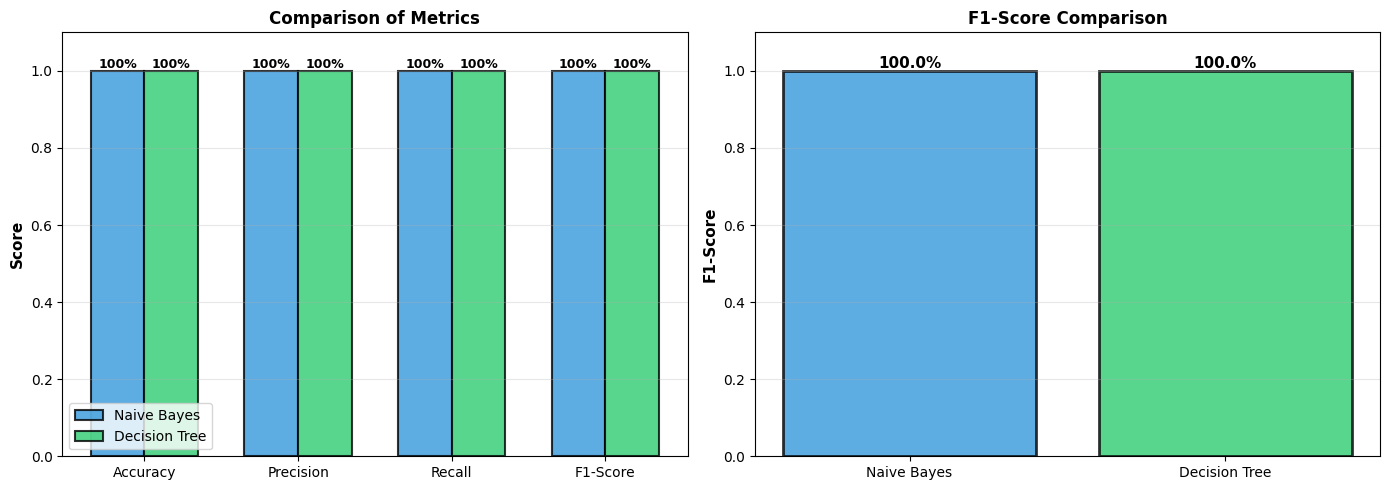

✅ แสดงกราฟเปรียบเทียบสำเร็จ


In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# กราฟที่ 1: เปรียบเทียบเมตริก
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
nb_values = [nb_accuracy_test, nb_precision, nb_recall, nb_f1]
dt_values = [dt_accuracy_test, dt_precision, dt_recall, dt_f1]

x = np.arange(len(metrics))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, nb_values, width, label='Naive Bayes',
                color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, dt_values, width, label='Decision Tree',
                color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.5)

ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_title('Comparison of Metrics', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=10)
ax1.legend(fontsize=10)
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)

# เพิ่มค่าบนแต่ละแท่ง
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# กราฟที่ 2: F1-Score เทียบเคียง
ax2 = axes[1]
models = ['Naive Bayes', 'Decision Tree']
f1_scores = [nb_f1, dt_f1]
colors = ['#3498db', '#2ecc71']
bars = ax2.bar(models, f1_scores, color=colors, alpha=0.8,
               edgecolor='black', linewidth=2)

ax2.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
ax2.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.grid(axis='y', alpha=0.3)

# เพิ่มค่า
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.1%}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ แสดงกราฟเปรียบเทียบสำเร็จ")

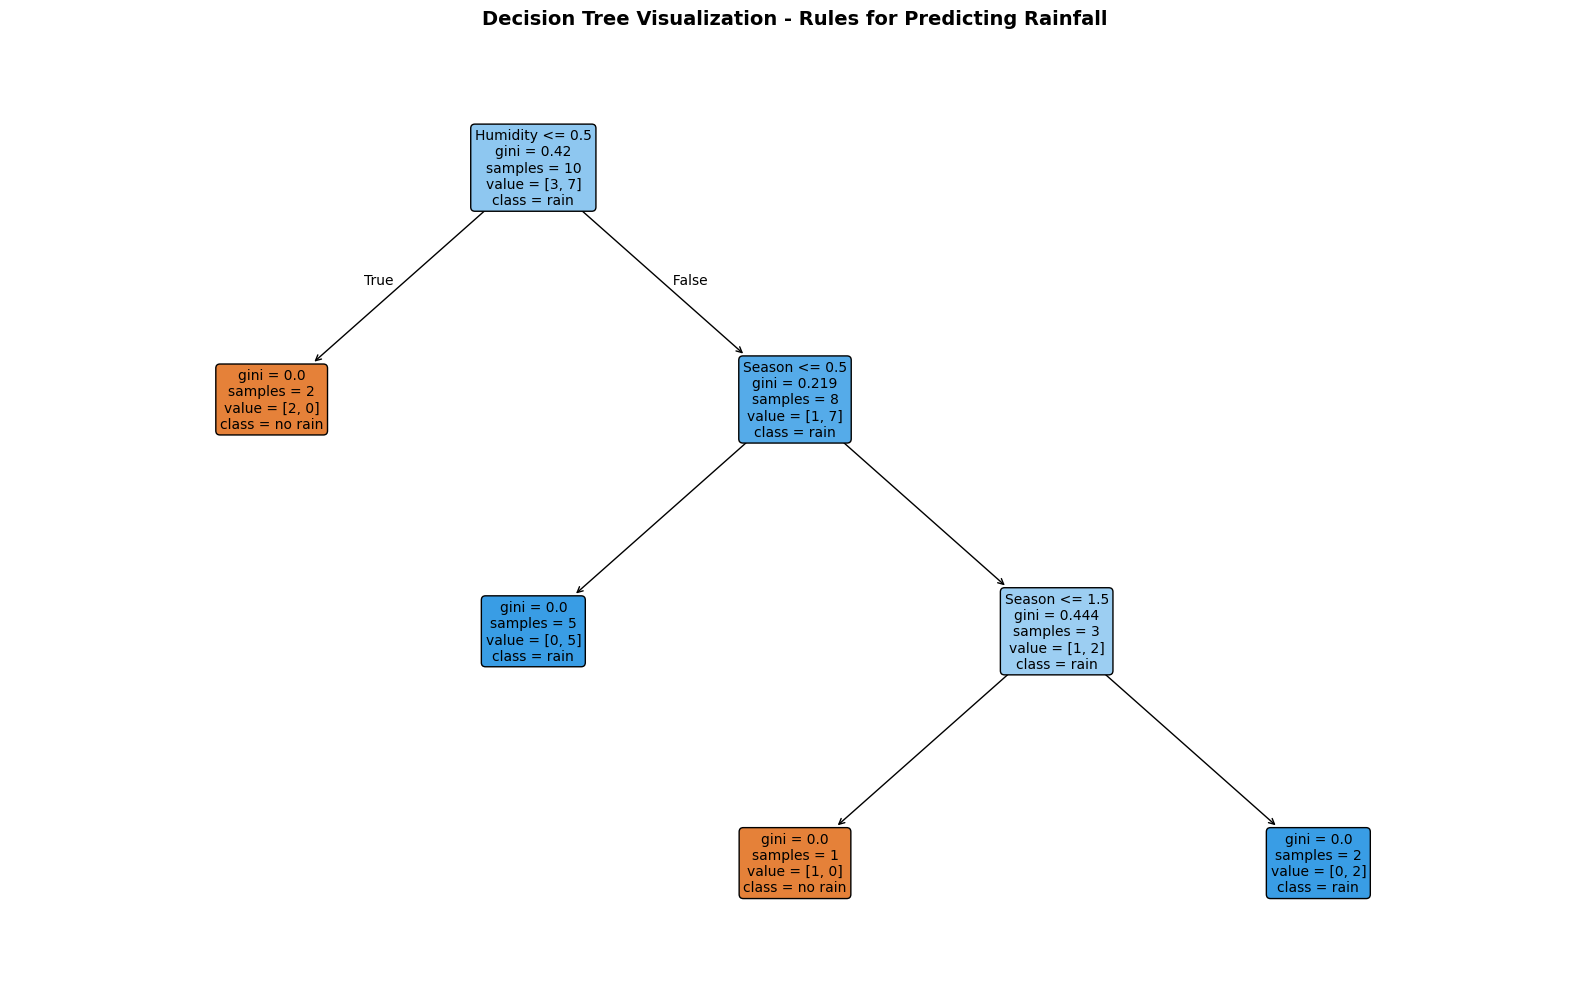

In [103]:
fig, ax = plt.subplots(figsize=(16, 10))
plot_tree(dt_model,
          feature_names=['Day', 'Season', 'Humidity', 'Cloud Cover'],
          class_names=le_target.classes_,
          filled=True,
          ax=ax,
          fontsize=10,
          rounded=True)
plt.title('Decision Tree Visualization - Rules for Predicting Rainfall',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()